# Clustering Analysis - Phân Cụm Người Dùng

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Thiết lập đường dẫn
BASE_DIR = Path.cwd().parent.parent
DATA_PATH = BASE_DIR / "outputs" / "data_split"/ "train.csv"
OUTPUT_DIR = BASE_DIR / "outputs" / "clustering"
MODELS_DIR = OUTPUT_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load và Tạo User Profiles

In [3]:
# Đọc dữ liệu interactions
df_interactions = pd.read_csv(DATA_PATH)

print(f"📊 Tổng số interactions: {len(df_interactions):,}")
print(f"👥 Số users: {df_interactions['user_idx'].nunique():,}")
df_interactions.head()

📊 Tổng số interactions: 6,862
👥 Số users: 2,454


,user_id,movie_id,movie_title,rating,cast,release_year,language,genres_list,primary_genre,genre_count,...,genre_thriller,genre_tv_movie,genre_war,genre_western,primary_genre_encoded,user_idx,movie_idx,source_encoded,year_scaled,genre_count_scaled
0,Sejian,1265609,War Machine,6.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,779,741,0,1.0,0.333333
1,MovieGuys,1265609,War Machine,6.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,600,741,0,1.0,0.333333
2,Dean,1265609,War Machine,9.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,248,741,0,1.0,0.333333
3,MovieGuys,1290821,Shelter,6.0,"Jason Statham, Bodhi Rae Breathnach, Michael S...",2026,en,"[""action"", ""crime"", ""thriller""]",action,3,...,1,0,0,0,0,600,797,0,1.0,0.333333
4,Kashifzia,799882,The Bluff,6.0,"Priyanka Chopra Jonas, Karl Urban, Safia Oakle...",2026,en,"[""action"", ""thriller""]",action,2,...,1,0,0,0,0,473,2283,0,1.0,0.166667


In [4]:
# Tạo user profiles
print("🔨 Đang tạo user profiles...")
user_profiles = []

for user_id in df_interactions['user_idx'].unique():
    user_data = df_interactions[df_interactions['user_idx'] == user_id]
    
    profile = {
        'user_idx': user_id,
        'avg_rating': user_data['rating_scaled'].mean(),
        'num_ratings': len(user_data),
        'rating_std': user_data['rating_scaled'].std(),
    }
    
    # Tính tỷ lệ xem từng thể loại
    genre_cols = [col for col in user_data.columns if col.startswith('genre_')]
    for genre in genre_cols:
        profile[f'{genre}_pref'] = user_data[genre].mean()
    
    user_profiles.append(profile)

df_user_profiles = pd.DataFrame(user_profiles)
print(f"✅ Đã tạo {len(df_user_profiles)} user profiles")
df_user_profiles.head()

🔨 Đang tạo user profiles...
✅ Đã tạo 2454 user profiles


,user_idx,avg_rating,num_ratings,rating_std,genre_count_pref,genre_action_pref,genre_adventure_pref,genre_animation_pref,genre_comedy_pref,genre_crime_pref,...,genre_mystery_pref,genre_romance_pref,genre_science_fiction_pref,genre_superhero_pref,genre_suspense_pref,genre_thriller_pref,genre_tv_movie_pref,genre_war_pref,genre_western_pref,genre_count_scaled_pref
0,779,0.607407,15,0.150640,2.800000,0.466667,0.266667,0.066667,0.133333,0.133333,...,0.133333,0.066667,0.400000,0.0,0.0,0.466667,0.0,0.000000,0.000000,0.300000
1,600,0.496224,103,0.183971,2.728155,0.601942,0.233010,0.009709,0.135922,0.165049,...,0.077670,0.029126,0.339806,0.0,0.0,0.533981,0.0,0.058252,0.009709,0.288026
2,248,0.632099,45,0.334864,2.533333,0.222222,0.177778,0.022222,0.066667,0.177778,...,0.288889,0.000000,0.200000,0.0,0.0,0.444444,0.0,0.000000,0.000000,0.255556
3,473,0.777778,3,0.192450,2.666667,1.000000,0.000000,0.000000,0.333333,0.333333,...,0.000000,0.000000,0.333333,0.0,0.0,0.666667,0.0,0.000000,0.000000,0.277778
4,545,0.650794,259,0.191917,2.841699,0.440154,0.370656,0.088803,0.220077,0.138996,...,0.108108,0.073359,0.320463,0.0,0.0,0.339768,0.0,0.019305,0.007722,0.306950


## 3. Chuẩn Bị Dữ Liệu

In [5]:
# Loại bỏ user_idx và chuẩn bị features
df_features = df_user_profiles.drop('user_idx', axis=1).fillna(0)

print(f"📊 Feature shape: {df_features.shape}")
print(f"   {df_features.shape[0]} users x {df_features.shape[1]} features")

📊 Feature shape: (2454, 29)
   2454 users x 29 features


In [6]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)

print("✅ Dữ liệu đã được chuẩn hóa")

✅ Dữ liệu đã được chuẩn hóa


## 4. Tìm Số Cụm Tối Ưu

Sử dụng Elbow Method và Silhouette Score để tìm K tối ưu.

In [7]:
# Thử nghiệm với các giá trị K khác nhau
k_range = range(2, 11)
silhouette_scores = []
davies_bouldin_scores = []
calinski_scores = []
inertias = []

print("🔍 Đang tìm K tối ưu...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    
    print(f"   K={k}: Silhouette={silhouette_scores[-1]:.4f}")

best_k = k_range[np.argmax(silhouette_scores)]
print(f"\n✅ K tối ưu: {best_k} (Silhouette Score: {max(silhouette_scores):.4f})")

🔍 Đang tìm K tối ưu...
   K=2: Silhouette=0.1940
   K=3: Silhouette=0.1283
   K=4: Silhouette=0.1179
   K=5: Silhouette=0.1500
   K=6: Silhouette=0.1103
   K=7: Silhouette=0.1485
   K=8: Silhouette=0.1492
   K=9: Silhouette=0.1430
   K=10: Silhouette=0.1983

✅ K tối ưu: 10 (Silhouette Score: 0.1983)


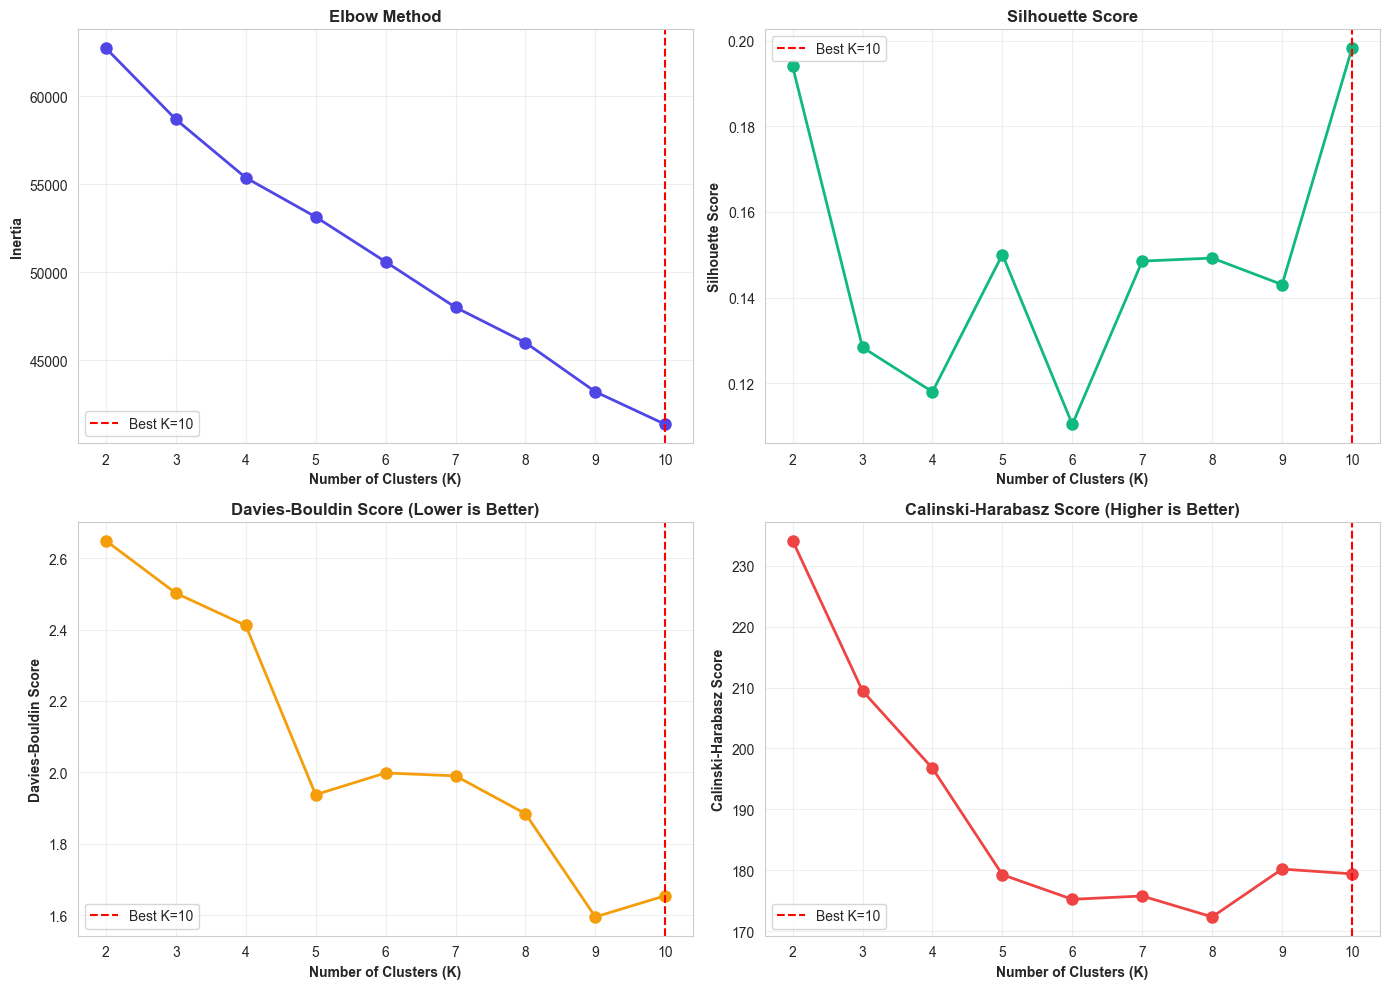

In [8]:
# Visualization: Elbow Method và Silhouette Score
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Elbow Method
axes[0, 0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8, color='#4f46e5')
axes[0, 0].axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
axes[0, 0].set_xlabel('Number of Clusters (K)', fontweight='bold')
axes[0, 0].set_ylabel('Inertia', fontweight='bold')
axes[0, 0].set_title('Elbow Method', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Subplot 2: Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='#10b981')
axes[0, 1].axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
axes[0, 1].set_xlabel('Number of Clusters (K)', fontweight='bold')
axes[0, 1].set_ylabel('Silhouette Score', fontweight='bold')
axes[0, 1].set_title('Silhouette Score', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Subplot 3: Davies-Bouldin Score (lower is better)
axes[1, 0].plot(k_range, davies_bouldin_scores, marker='o', linewidth=2, markersize=8, color='#f59e0b')
axes[1, 0].axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
axes[1, 0].set_xlabel('Number of Clusters (K)', fontweight='bold')
axes[1, 0].set_ylabel('Davies-Bouldin Score', fontweight='bold')
axes[1, 0].set_title('Davies-Bouldin Score (Lower is Better)', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Subplot 4: Calinski-Harabasz Score (higher is better)
axes[1, 1].plot(k_range, calinski_scores, marker='o', linewidth=2, markersize=8, color='#ef4444')
axes[1, 1].axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
axes[1, 1].set_xlabel('Number of Clusters (K)', fontweight='bold')
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontweight='bold')
axes[1, 1].set_title('Calinski-Harabasz Score (Higher is Better)', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clustering_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Thực Hiện Phân Cụm với K Tối Ưu

In [9]:
# Phân cụm với K tối ưu
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans_model.fit_predict(X_scaled)

print(f"✅ Đã phân cụm với K={best_k}")

# Phân phối các cụm
unique, counts = np.unique(labels, return_counts=True)
print(f"\n📊 Phân phối cụm:")
for cid, count in zip(unique, counts):
    print(f"   Cluster {cid}: {count} users ({count/len(labels)*100:.1f}%)")

✅ Đã phân cụm với K=10

📊 Phân phối cụm:
   Cluster 0: 298 users (12.1%)
   Cluster 1: 198 users (8.1%)
   Cluster 2: 273 users (11.1%)
   Cluster 3: 255 users (10.4%)
   Cluster 4: 520 users (21.2%)
   Cluster 5: 501 users (20.4%)
   Cluster 6: 168 users (6.8%)
   Cluster 7: 168 users (6.8%)
   Cluster 8: 22 users (0.9%)
   Cluster 9: 51 users (2.1%)


## 6. Đánh Giá Kết Quả

In [10]:
# Tính các metrics
silhouette = silhouette_score(X_scaled, labels)
davies_bouldin = davies_bouldin_score(X_scaled, labels)
calinski = calinski_harabasz_score(X_scaled, labels)

print("📊 Đánh giá chất lượng phân cụm:")
print(f"   Silhouette Score: {silhouette:.4f}")
print(f"   Davies-Bouldin Score: {davies_bouldin:.4f}")
print(f"   Calinski-Harabasz Score: {calinski:.4f}")

if silhouette > 0.5:
    quality = 'Tốt'
elif silhouette > 0.3:
    quality = 'Trung bình'
else:
    quality = 'Yếu'
    
print(f"\n   Chất lượng: {quality}")

📊 Đánh giá chất lượng phân cụm:
   Silhouette Score: 0.1983
   Davies-Bouldin Score: 1.6547
   Calinski-Harabasz Score: 179.4034

   Chất lượng: Yếu


## 7. PCA Visualization

In [11]:
# Giảm chiều xuống 2D bằng PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"📊 PCA Explained Variance:")
print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

📊 PCA Explained Variance:
   PC1: 13.06%
   PC2: 7.97%
   Total: 21.03%


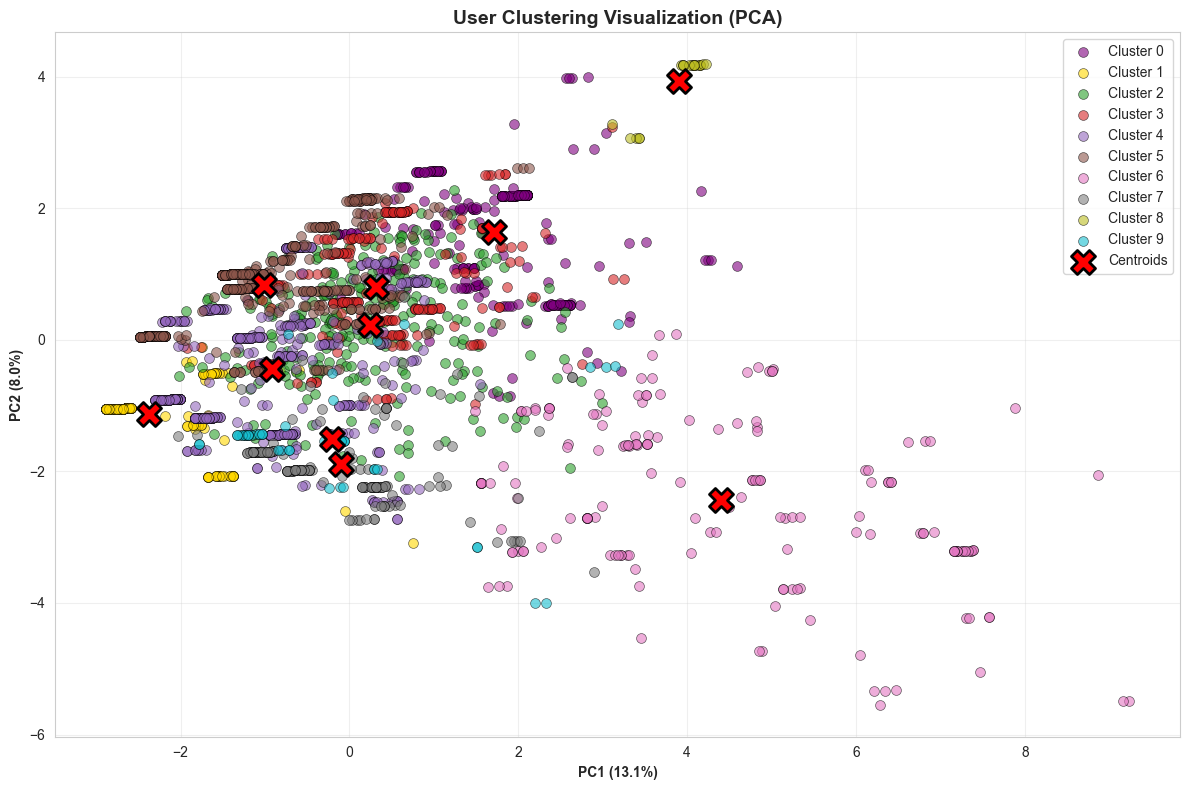

✓ Đã lưu biểu đồ PCA: c:\Users\HP\Downloads\Smart-Movie-Recommender-main\outputs\clustering\clustering_pca.png
✓ Đã lưu biểu đồ phân bố: c:\Users\HP\Downloads\Smart-Movie-Recommender-main\outputs\clustering\cluster_distribution.png


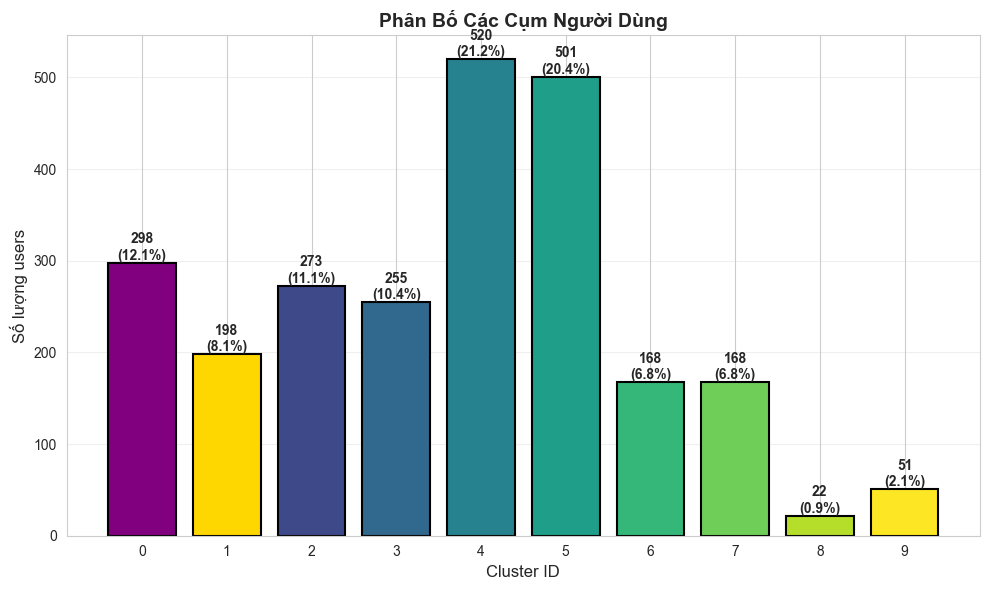

In [12]:
# =========================
# Thiết lập màu sắc thống nhất
# =========================
custom_colors = {
    0: 'purple',   # Cluster 0
    1: 'gold'      # Cluster 1
}

# =========================
# 1. Scatter Plot với PCA
# =========================
plt.figure(figsize=(12, 8))

default_scatter_colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for i in range(best_k):
    mask = labels == i
    color = custom_colors.get(i, default_scatter_colors[i])

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=[color],
        label=f'Cluster {i}',
        alpha=0.6,
        s=50,
        edgecolors='black',
        linewidth=0.5
    )

# Vẽ tâm cụm
centroids_pca = pca.transform(kmeans_model.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    marker='X',
    s=300,
    edgecolors='black',
    linewidth=2,
    label='Centroids'
)

plt.xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)',
    fontweight='bold'
)
plt.ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)',
    fontweight='bold'
)
plt.title(
    'User Clustering Visualization (PCA)',
    fontweight='bold',
    fontsize=14
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "clustering_pca.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# =========================
# 2. Biểu đồ phân bố cụm
# =========================
plt.figure(figsize=(10, 6))

unique, counts = np.unique(labels, return_counts=True)

default_bar_colors = plt.cm.viridis(np.linspace(0, 1, len(unique)))
bar_colors = [
    custom_colors.get(cluster_id, default_bar_colors[i])
    for i, cluster_id in enumerate(unique)
]

bars = plt.bar(
    unique,
    counts,
    color=bar_colors,
    edgecolor='black',
    linewidth=1.5
)

plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Số lượng users', fontsize=12)
plt.title('Phân Bố Các Cụm Người Dùng', fontsize=14, fontweight='bold')
plt.xticks(unique)

# Thêm số lượng và tỷ lệ trên mỗi cột
for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(count)}\n({count / len(labels) * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / 'cluster_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

print(f"✓ Đã lưu biểu đồ PCA: {OUTPUT_DIR / 'clustering_pca.png'}")
print(f"✓ Đã lưu biểu đồ phân bố: {OUTPUT_DIR / 'cluster_distribution.png'}")

plt.show()

## 8. Phân Tích Đặc Điểm Từng Cụm

In [13]:
# Thêm labels vào user profiles
df_with_clusters = df_user_profiles.copy()
df_with_clusters['user_cluster'] = labels

# Phân tích từng cụm
cluster_profiles = []

for cluster_id in range(best_k):
    cluster_data = df_with_clusters[df_with_clusters['user_cluster'] == cluster_id]
    
    profile = {
        'cluster_id': cluster_id,
        'num_users': len(cluster_data),
        'percentage': len(cluster_data) / len(df_user_profiles) * 100,
        'avg_rating': cluster_data['avg_rating'].mean(),
        'avg_num_ratings': cluster_data['num_ratings'].mean(),
        'avg_rating_std': cluster_data['rating_std'].mean()
    }
    
    # Top 5 thể loại
    genre_pref_cols = [col for col in cluster_data.columns if col.endswith('_pref')]
    if genre_pref_cols:
        genre_means = cluster_data[genre_pref_cols].mean().sort_values(ascending=False)
        top_5_genres = genre_means.head(5)
        
        profile['top_genres'] = []
        for genre, score in top_5_genres.items():
            genre_name = genre.replace('genre_', '').replace('_pref', '')
            profile['top_genres'].append({
                'genre': genre_name,
                'preference_score': float(score)
            })
    
    cluster_profiles.append(profile)

# Hiển thị cluster profiles
profiles_df = pd.DataFrame(cluster_profiles)
print("📊 Cluster Profiles:")
profiles_df

📊 Cluster Profiles:


,cluster_id,num_users,percentage,avg_rating,avg_num_ratings,avg_rating_std,top_genres
0,0,298,12.143439,0.599783,1.268456,0.089886,"[{'genre': 'count', 'preference_score': 3.0111..."
1,1,198,8.068460,0.481996,1.060606,0.105112,"[{'genre': 'count', 'preference_score': 1.3030..."
2,2,273,11.124694,0.582061,15.278388,0.243622,"[{'genre': 'count', 'preference_score': 2.4950..."
3,3,255,10.391198,0.578903,1.149020,0.053022,"[{'genre': 'count', 'preference_score': 2.9078..."
4,4,520,21.189894,0.484531,1.198077,0.075138,"[{'genre': 'count', 'preference_score': 1.8097..."
5,5,501,20.415648,0.459595,1.297405,0.090266,"[{'genre': 'count', 'preference_score': 2.1348..."
6,6,168,6.845966,0.616200,1.422619,0.128226,"[{'genre': 'count', 'preference_score': 3.8609..."
7,7,168,6.845966,0.515123,1.303571,0.113739,"[{'genre': 'count', 'preference_score': 2.5246..."
8,8,22,0.896496,0.497475,1.090909,0.039284,"[{'genre': 'count', 'preference_score': 4.0}, ..."
9,9,51,2.078240,0.557734,1.078431,0.117851,"[{'genre': 'count', 'preference_score': 2.7352..."


In [14]:
# Hiển thị chi tiết từng cụm
for profile in cluster_profiles:
    print(f"\n{'='*60}")
    print(f"🎯 CLUSTER {profile['cluster_id']}")
    print(f"{'='*60}")
    print(f"   Số users: {profile['num_users']} ({profile['percentage']:.1f}%)")
    print(f"   Avg rating: {profile['avg_rating']:.2f}")
    print(f"   Avg num ratings: {profile['avg_num_ratings']:.1f}")
    print(f"   Avg rating std: {profile['avg_rating_std']:.2f}")
    print(f"\n   Top 5 Genres:")
    for i, genre_info in enumerate(profile['top_genres'], 1):
        print(f"      {i}. {genre_info['genre']}: {genre_info['preference_score']:.3f}")


🎯 CLUSTER 0
   Số users: 298 (12.1%)
   Avg rating: 0.60
   Avg num ratings: 1.3
   Avg rating std: 0.09

   Top 5 Genres:
      1. count: 3.011
      2. action: 0.838
      3. science_fiction: 0.737
      4. adventure: 0.718
      5. count_scaled: 0.335

🎯 CLUSTER 1
   Số users: 198 (8.1%)
   Avg rating: 0.48
   Avg num ratings: 1.1
   Avg rating std: 0.11

   Top 5 Genres:
      1. count: 1.303
      2. documentary: 0.988
      3. music: 0.114
      4. crime: 0.081
      5. drama: 0.055

🎯 CLUSTER 2
   Số users: 273 (11.1%)
   Avg rating: 0.58
   Avg num ratings: 15.3
   Avg rating std: 0.24

   Top 5 Genres:
      1. count: 2.495
      2. thriller: 0.340
      3. action: 0.298
      4. drama: 0.288
      5. comedy: 0.257

🎯 CLUSTER 3
   Số users: 255 (10.4%)
   Avg rating: 0.58
   Avg num ratings: 1.1
   Avg rating std: 0.05

   Top 5 Genres:
      1. count: 2.908
      2. crime: 0.953
      3. thriller: 0.545
      4. action: 0.342
      5. count_scaled: 0.318

🎯 CLUSTER 4
   Số u

## 9. Lưu Kết Quả

In [15]:
# Lưu cluster profiles (Parquet)
profiles_save = profiles_df.copy()
if 'top_genres' in profiles_save.columns:
    profiles_save['top_genres'] = profiles_save['top_genres'].apply(json.dumps)

profiles_save.to_parquet(OUTPUT_DIR / 'user_cluster_profiles.parquet', engine='pyarrow', index=False)
print("✅ Đã lưu user_cluster_profiles.parquet")

✅ Đã lưu user_cluster_profiles.parquet


In [16]:
# Lưu users với labels (Parquet)
df_with_clusters.to_parquet(OUTPUT_DIR / 'users_clustered.parquet', engine='pyarrow', index=False)
print("✅ Đã lưu users_clustered.parquet")

✅ Đã lưu users_clustered.parquet


In [17]:
# Lưu models
joblib.dump(kmeans_model, MODELS_DIR / 'kmeans_users.pkl')
joblib.dump(scaler, MODELS_DIR / 'user_clustering_scaler.pkl')
joblib.dump(pca, MODELS_DIR / 'user_clustering_pca.pkl')
print("✅ Đã lưu models")

✅ Đã lưu models


In [18]:
# Lưu metrics
metrics = {
    'num_users': len(df_user_profiles),
    'num_features': df_features.shape[1],
    'k_analysis': {
        'k_values': list(k_range),
        'inertias': inertias,
        'silhouette_scores': silhouette_scores,
        'davies_bouldin_scores': davies_bouldin_scores,
        'calinski_harabasz_scores': calinski_scores,
        'best_k': best_k,
        'best_silhouette': max(silhouette_scores)
    },
    'cluster_distribution': {f'cluster_{int(cid)}': int(count) for cid, count in zip(unique, counts)},
    'cluster_percentages': {f'cluster_{int(cid)}': float(count / len(labels) * 100) for cid, count in zip(unique, counts)},
    'silhouette_score': float(silhouette),
    'davies_bouldin_score': float(davies_bouldin),
    'calinski_harabasz_score': float(calinski),
    'quality': quality,
    'pca': {
        'n_components': 2,
        'explained_variance_ratio': pca.explained_variance_ratio_.tolist(),
        'total_explained_variance': float(sum(pca.explained_variance_ratio_))
    },
    'cluster_profiles': cluster_profiles
}

with open(OUTPUT_DIR / 'clustering_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print("✅ Đã lưu clustering_metrics.json")

✅ Đã lưu clustering_metrics.json


## 10. Tổng Kết

Quá trình phân cụm người dùng đã hoàn thành:

- **Thuật toán**: K-Means
- **Số cụm tối ưu**: {best_k}
- **Silhouette Score**: {silhouette:.4f}
- **Chất lượng**: {quality}
- **Outputs**: user_cluster_profiles.parquet, users_clustered.parquet, models, clustering_metrics.json